In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import MultipleLocator
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 14
})

### Non-linear efficiency

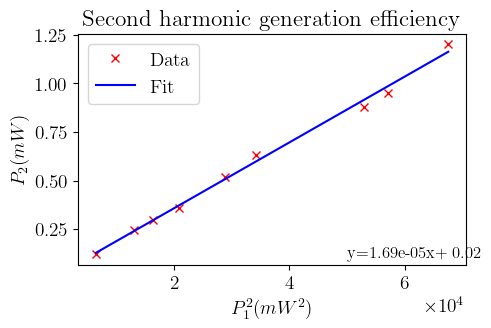

Non-linear efficiency= 1.6892090289407227 %/W


In [31]:
P1_list = np.array([80, 114, 128, 144, 170, 185, 230, 239, 260])
P2_list = np.array([0.12, 0.248, 0.295, 0.360, 0.520, 0.63, 0.88, 0.95, 1.20])
E_NL, b = np.polyfit(P1_list**2,P2_list, 1)

fig, ax = plt.subplots(figsize=(5,3))
ax.plot(P1_list**2, P2_list, 'rx', label='Data')
ax.plot(P1_list**2, E_NL*P1_list**2 + b, 'b-', label='Fit')
# Forcer la notation scientifique
ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
ax.set_xlabel("$P_1^2 (mW^2)$")
ax.set_ylabel("$P_2 (mW)$")
ax.set_title("Second harmonic generation efficiency")
ax.text(50000, 0.1, f"y={E_NL:.2e}x+ {b:.2f}", fontsize=12)
ax.legend()
plt.show()

print("Non-linear efficiency=", E_NL*100*1000,"%/W")


### Phase-matching temperature

[0.0008812337862931813, 0.00027463187638551717, -7.25325e-08]


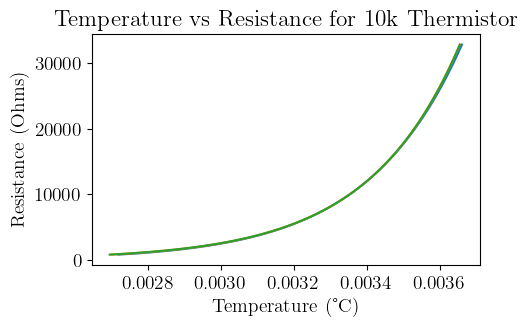

In [30]:
R_list = np.linspace(800,32770,1000)  # Resistance values in ohms


# We need to convert the resistance R into temperature T 
# https://www.thorlabs.com/item/TH10K
R = 10e3  # Resistance in ohms at 25 degrees Celsius
L25 = np.log(R)

def T(r) : 
    if r < 3560:
        a, b, c, d = 0.003353045, 0.0002542, 1.14261e-6, -6.93803e-8
        #A, B, gam, C = a - b*L25 + c*L25**2 - d*L25**3, b-2*c*L25 + 3*d*L25**2, -3*d*L25+c, d
        A, B, C = a - b*L25 + 2*d*L25**3, b-3*d*L25**2, d
    if r >= 3560:
        a, b, c, d = 0.003354016, 0.000256173, 2.13941e-6, -7.25325e-8
        A, B, C = a - b*L25 + 2*d*L25**3, b-3*d*L25**2, d
        #A, B, gam, C = a - b*L25 + c*L25**2 - d*L25**3, b-2*c*L25 + 3*d*L25**2, -3*d*L25+c, d
    T1 = 1 / (a + b * np.log(r / R) + c * (np.log(r / R))**2 + d * (np.log(r / R))**3) 
    T2 = 1/(A+B*np.log(r)+C*np.log(r)**3) 
    return 1/T1, 1/T2, A, B, C

plt.subplots(figsize=(5,3))
plt.plot([T(r)[0] for r in R_list], R_list)
plt.plot([T(r)[1] for r in R_list], R_list)
plt.plot([(8.812338e-4+2.746319e-4*np.log(r)-7.25325e-8*np.log(r)**3) for r in R_list], R_list)
#plt.xlim(0,50)
plt.xlabel("Temperature (°C)")
plt.ylabel("Resistance (Ohms)")
plt.title("Temperature vs Resistance for 10k Thermistor")

print([T(r=4000)[i] for i in range(2,5)])

In [5]:
a, b, c, d = 0.003353045, 0.0002542, 1.14261e-6, -6.93803e-8
gamma = -3*d*L25 + c
print(gamma)

3.059658534329457e-06


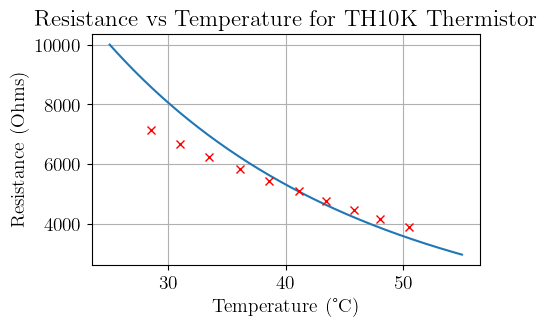

In [53]:
R = 10e3  # Resistance in ohms at 25 degrees Celsius
R_curs = 332
R2 = 4.42e3  
R3 = 10e3
R4 = 33.2e3
R15 = 10e3
R14 = 178e3
R34 = R3*R4/(R3+R4)
R1415 = R14*R15/(R14+R15)
T_list = np.linspace(25,55,1000)  # Temperature values in Celsius
list_T = np.array([28.5, 31, 33.5, 36.1, 38.6, 41.1, 43.4, 45.8, 48, 50.5])  # liste of temperatures in Celsius for cursor i=3...9
list_n = np.array([1,2,3,4,5,6,7,8,9,10])  # liste of cursor positions i=3...9


# Resistance as function of the cursor temperature n (big) and alpha (small)
def R_n_alpha(n, alpha):
    return R2*(R1415+(10-n)*R_curs)/(R34+(n-1)*R_curs)


# We need to convert the temperature T into resistance R 
# https://www.thorlabs.com/item/TH10K
def Res(Temp) : 
    if Temp < 50:
        A, B, C, D = -15.4668, 5599.4257, -378107.9210, 24906735.1935
    if Temp >= 50:
        A, B, C, D = -14.8060, 5153.6849, -296745.7239, 22860787.7442
    return R * np.exp(A + B / (Temp + 273.15) + C / (Temp + 273.15)**2 + D / (Temp + 273.15)**3)

fig, ax = plt.subplots(figsize = (5,3))

ax.plot(T_list, [Res(T) for T in T_list])
ax.plot(list_T, [R_n_alpha(n, alpha=0) for n in list_n], 'rx')

ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Resistance (Ohms)")
ax.set_title("Resistance vs Temperature for TH10K Thermistor")
ax.grid(True)



/var/folders/z4/n7yq_g310r99kb95d_7_r8p00000gn/T/ipykernel_10562/2275971945.py:21: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


Paramètres ajustés :
a = 10000.000000
b = -13232.885220
d = -16217.844710
RMSE = 6.302 ohms


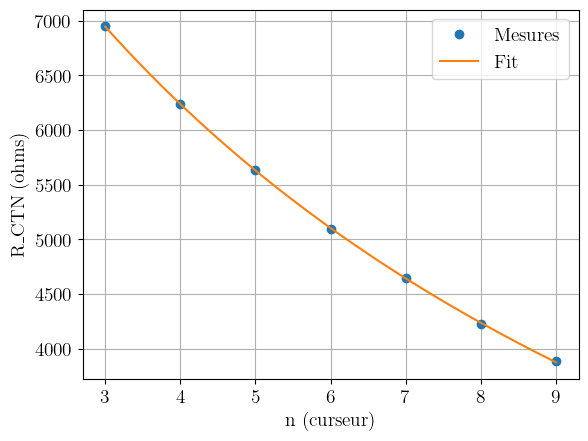

In [37]:
import numpy as np
from scipy.optimize import curve_fit

# données
n = np.array([3, 4, 5, 6, 7, 8, 9], dtype=float)
R = np.array([
    6948.759966230796,
    6238.676880256252,
    5632.90808130719,
    5093.305366841102,
    4648.4373434320305,
    4230.873441289299,
    3885.3981045998785
])

# modèle
def model(n, a, b, d):
    return R2*(332*n + b) / (d-b - 332*n)

# fit
popt, pcov = curve_fit(
    model, n, R,
    p0=[1e4, -1e3, 10]  # estimation initiale
)


a, b, d = popt

print("Paramètres ajustés :")
print(f"a = {a:.6f}")
print(f"b = {b:.6f}")
print(f"d = {d:.6f}")

# erreur RMS
R_fit = model(n, *popt)
rmse = np.sqrt(np.mean((R - R_fit)**2))
print(f"RMSE = {rmse:.3f} ohms")

import matplotlib.pyplot as plt

n_fine = np.linspace(3, 9, 200)
plt.plot(n, R, 'o', label='Mesures')
plt.plot(n_fine, model(n_fine, *popt), '-', label='Fit')
plt.xlabel("n (curseur)")
plt.ylabel("R_CTN (ohms)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
R_list = np.array([])
P2_list = np.array([])
T_list = [T(r=r) for r in R_list]
plt.plot(T_list, P2_list)
print("Phase-matching temperature is:", T_list[np.argmax(P2_list)])

### SHG efficiency

In [3]:
#Input field
E1 = np.sqrt(0.6)

#Non linear efficiency 
Enl = 0.0169


#Reflexion and transmission coeff
r1 = np.sqrt(1 - 0.12)
t1 = np.sqrt(1 - r1**2)
r2 = 1
t2 = np.sqrt(1 - r2**2)
r3 = 1
t3 = np.sqrt(1 - r3**2)
r4 = 1
t4 = np.sqrt(1 - r4**2)

#Linear losses
Lc = 0.02

#Losses due to non linear conversion
gamma = Enl

#Cavity field
#Ec = E1 * t1 / (1-r1*r2*r3*r4*np.sqrt(1 - gamma*Ec**2))

#New variables
lambd = t1**2 + Lc
rho = 4*t1**2*E1**2*Enl

#Ouput field
u = 1 + 13.5*rho/lambd**3*(1 + np.sqrt(1 + 4/27*lambd**3/rho))
P2 = lambd**2 / (9*Enl) * (u**(1/6) - u**(-1/6))**4

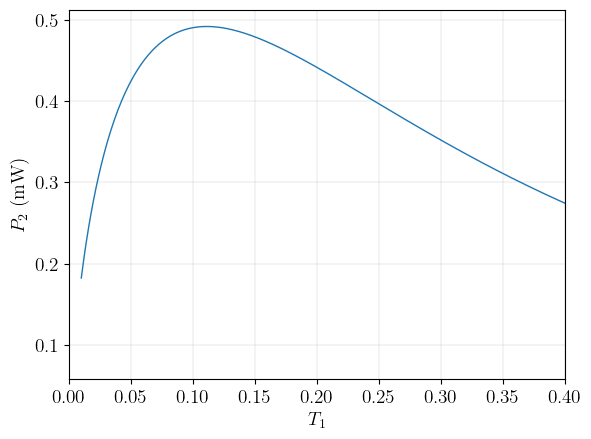

In [4]:
#Plot output field vs transmission for a fixed input field

def output_field(T1, E1) : 
    lambd = T1 + Lc
    rho = 4*T1*E1**2*Enl
    u = 1+13.5*rho/lambd**3*(1 + np.sqrt(1 + 4/27*lambd**3/rho))
    v = 1+13.5*rho/lambd**3*(1 - np.sqrt(1 + 4/27*lambd**3/rho))
    P2 = lambd**2 / (9*Enl) * (u**(1/6) - u**(-1/6))**4
    return P2

transmission = np.linspace(0.01,1,1000)
out_field = [output_field(t, E1=np.sqrt(0.6)) for t in transmission]

fig, ax = plt.subplots()

ax.plot(transmission, out_field, linewidth = 1)
ax.set_xlabel('$T_1$')
ax.set_ylabel('$P_2$ (mW)')
ax.set_xlim(0, 0.4)
ax.grid(linewidth = 0.2)
plt.show()

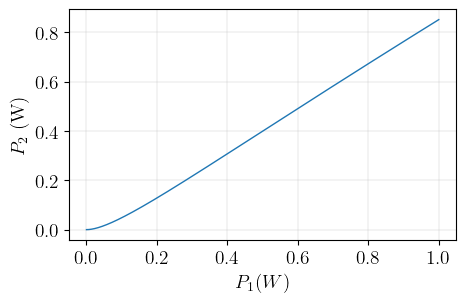

In [5]:
#Plot output field vs input field for a fixed transmission

input_field = np.linspace(0.01,1,1000)
out_field = [output_field(T1=0.12, E1=inp) for inp in input_field]

fig, ax = plt.subplots(figsize=(5,3))

ax.plot(input_field**2, out_field, linewidth = 1)
ax.set_xlabel('$P_1 (W)$')
ax.set_ylabel('$P_2$ (W)')
ax.grid(linewidth = 0.2)
plt.show()

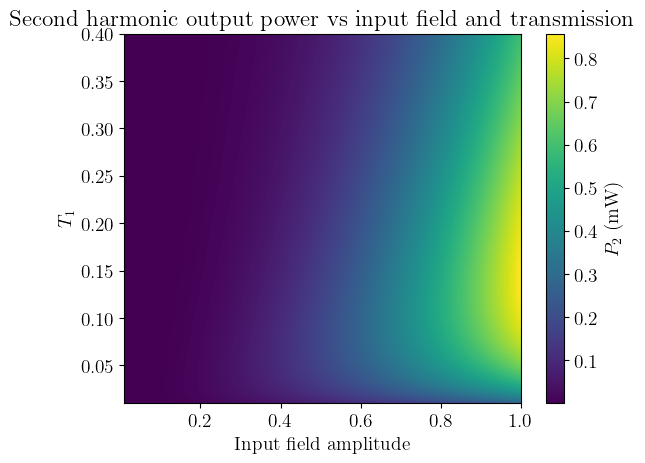

In [6]:
#Plot output field vs input field and transmission

transmission = np.linspace(0.01,0.4,1000)
input_field = np.linspace(0.01,1,1000)
out_field = np.zeros((len(transmission), len(input_field)))
for i, T1 in enumerate(transmission):
    for j, E1 in enumerate(input_field):
        out_field[i, j] = output_field(T1, E1)

plt.imshow(out_field, extent=(0.01,1,0.01,0.4), origin='lower', aspect='auto')
plt.colorbar(label='$P_2$ (mW)')
plt.ylabel('$T_1$')
plt.xlabel('Input field amplitude')
plt.title('Second harmonic output power vs input field and transmission')
plt.show()

Text(0.5, 1.0, 'Transmission at which SHG output is maximum vs input power')

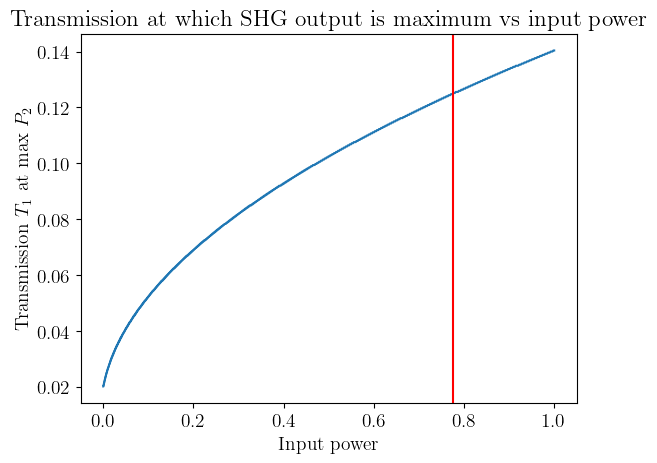

In [7]:
#Plot transmission at which SHG output is maximum vs input field amplitude

transmission = np.linspace(0.01,0.4,1000)
input_field = np.linspace(0.01,1,1000)
out_field = np.zeros((len(transmission), len(input_field)))
for i, T1 in enumerate(transmission):
    for j, E1 in enumerate(input_field):
        out_field[i, j] = output_field(T1, E1)

list_max_T1 = []
for j, E1 in enumerate(input_field):
    column = out_field[:, j]
    max_index = np.argmax(column)
    list_max_T1.append(transmission[max_index])

fig, ax = plt.subplots()
ax.plot(input_field**2, list_max_T1)
ax.set_xlabel('Input power')
ax.set_ylabel('Transmission $T_1$ at max $P_2$')
ax.axvline(np.sqrt(0.6), color='r')
ax.set_title('Transmission at which SHG output is maximum vs input power')

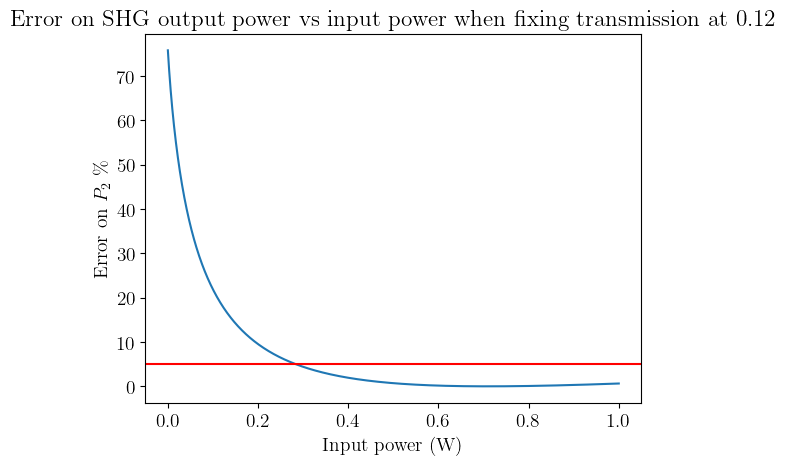

In [8]:
#Error on SHG output power when fixing transmission at 0.12 vs input field

error_P2 = []

for j, E1 in enumerate(input_field):
    max_P2 = out_field[:, j].max()
    P2_fixed_T1 = output_field(0.12, E1)
    error = abs(max_P2 - P2_fixed_T1) / max_P2 * 100
    error_P2.append(error)  

fig, ax = plt.subplots()
ax.plot(input_field**2, error_P2)
ax.set_xlabel('Input power (W)')
ax.set_ylabel(r'Error on $P_2$ \%')
ax.axhline(5, color='r')
ax.set_title('Error on SHG output power vs input power when fixing transmission at 0.12')
plt.show()  